In [50]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

d:\Property Intelligence Platform


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [52]:
from src.data.ingestion import load_data

df = load_data("../data/feature_engineered/gurgaon_properties_outlier_treated.csv")

Dataset loaded successfully.
Rows: 3555
Columns: 24


In [53]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,1743.0,Built Up area: 1743 (161.93 sq.m.),4,4,3,4.0,NaN,Undefined,NaN,1743.0,NaN,0,0,0,0,0,0,0,435.750000
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,16.0,NaN,New Property,2090.0,NaN,NaN,0,1,0,0,0,0,107,524.250000
2,house,unitech uniworld resorts,sector 33,8.00,11429.0,7000.0,Plot area 7000(650.32 sq.m.),4,4,3+,2.0,West,Old Property,NaN,7000.0,NaN,1,1,1,1,0,0,77,1750.000000
3,flat,ireo the corridors,sector 67a,1.60,9265.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,3.0,North,New Property,1727.0,NaN,1017.0,0,0,1,0,0,1,142,575.666667
4,house,rwa sector 46,sector 46,4.50,24390.0,1845.0,Plot area 204(170.57 sq.m.)Built Up area: 206 ...,6,6,3+,3.0,North-East,Moderately Old,NaN,206.0,205.0,0,0,1,0,0,1,80,307.500000


In [54]:
df.shape

(3555, 24)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3555 entries, 0 to 3554
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3555 non-null   object 
 1   society              3554 non-null   object 
 2   sector               3555 non-null   object 
 3   price                3555 non-null   float64
 4   price_per_sqft       3555 non-null   float64
 5   area                 3555 non-null   float64
 6   areaWithType         3555 non-null   object 
 7   bedRoom              3555 non-null   int64  
 8   bathroom             3555 non-null   int64  
 9   balcony              3555 non-null   object 
 10  floorNum             3538 non-null   float64
 11  facing               2544 non-null   object 
 12  agePossession        3555 non-null   object 
 13  super_built_up_area  1875 non-null   float64
 14  built_up_area        1586 non-null   float64
 15  carpet_area          1840 non-null   f

In [56]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1969
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### Buildup Area 

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

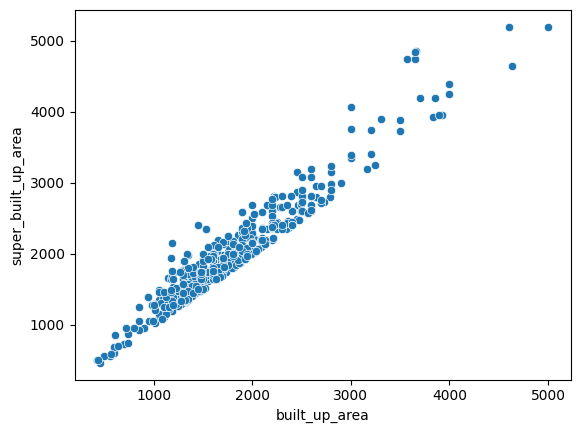

In [57]:
sns.scatterplot(data=df,x='built_up_area',y='super_built_up_area')

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

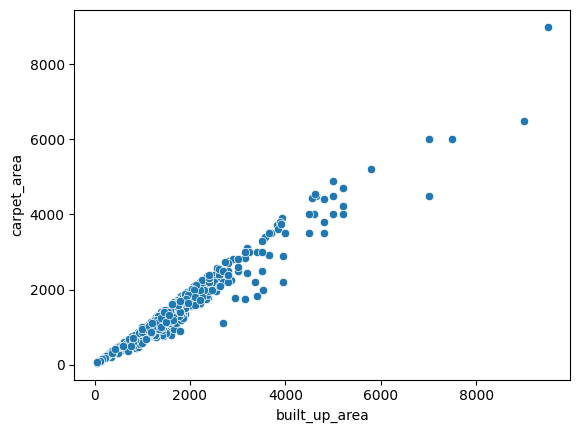

In [58]:
sns.scatterplot(data=df,x='built_up_area',y='carpet_area')

In [59]:
all_present_df=df[~((df['built_up_area'].isnull()) | (df['super_built_up_area'].isnull()) | (df['carpet_area'].isnull()))]
all_present_df.shape

(531, 24)

In [60]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [61]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [62]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [63]:
# both super built up area and carpet area are present built up no present
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [64]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
3,flat,ireo the corridors,sector 67a,1.60,9265.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,3.0,North,New Property,1727.0,NaN,1017.00,0,0,1,0,0,1,142,575.666667
32,flat,umang winter hills,sector 77,0.92,5049.0,1822.0,Super Built up area 1822(169.27 sq.m.)Carpet a...,3,3,3,17.0,North-East,Relatively New,1822.0,NaN,1400.00,0,0,0,0,1,1,49,607.333333
33,flat,tarc maceo,sector 91,0.87,6641.0,1310.0,Super Built up area 1310(121.7 sq.m.)Carpet ar...,2,2,2,9.0,North-West,Relatively New,1310.0,NaN,1000.00,0,0,1,0,0,0,78,655.000000
38,flat,dlf the ultima,sector 81,2.35,11233.0,2092.0,Super Built up area 2092(194.35 sq.m.)Carpet a...,3,4,3+,18.0,North,Relatively New,2092.0,NaN,1100.00,0,1,0,0,0,0,106,697.333333
41,flat,puri the aravallis,sector 61,3.87,17200.0,2250.0,Super Built up area 2250(209.03 sq.m.)Carpet a...,3,4,3+,21.0,East,Under Construction,2250.0,NaN,1249.65,0,1,0,0,0,0,58,750.000000


In [65]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_12680\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_12680\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

In [66]:
df.update(sbc_df)

In [67]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1548
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [68]:
# only super built up area is present built up and carpet area no present
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [69]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,2097.0,Super Built up area 2090(194.17 sq.m.),4,4,2,16.0,NaN,New Property,2090.0,NaN,NaN,0,1,0,0,0,0,107,524.250000
9,flat,tulip violet,sector 69,1.72,8731.0,1970.0,Super Built up area 1970(183.02 sq.m.),4,4,1,12.0,North-East,Relatively New,1970.0,NaN,NaN,0,0,0,0,0,0,86,492.500000
11,flat,smart world orchard,sector 61,2.24,14461.0,1549.0,Super Built up area 1549(143.91 sq.m.),3,3,2,3.0,NaN,New Property,1549.0,NaN,NaN,0,0,0,0,1,0,61,516.333333
12,flat,tulip violet,sector 69,1.38,8973.0,1538.0,Super Built up area 1538(142.88 sq.m.),3,3,1,12.0,East,Relatively New,1538.0,NaN,NaN,0,0,0,0,0,0,157,512.666667
15,flat,ramprastha primera,sector 37d,1.02,6000.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,2,3,22.0,NaN,Under Construction,1700.0,NaN,NaN,0,0,0,0,0,0,43,566.666667


In [70]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_12680\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_12680\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round

In [71]:
df.update(sb_df)

In [72]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area           673
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [73]:
# super built up area no present built up not present and carpet area present
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [74]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
7,flat,vatika boulevard residences and heights,sector 83,1.42,8000.0,1775.0,Carpet area: 1775 (164.9 sq.m.),3,3,2,2.0,West,Relatively New,NaN,NaN,1775.0,0,0,0,0,0,1,113,591.666667
14,flat,nul,gwal pahari,0.56,6054.0,925.0,Carpet area: 925 (85.94 sq.m.),2,2,1,11.0,NaN,Old Property,NaN,NaN,925.0,0,0,0,0,0,1,0,462.500000
17,flat,godrej air,sector 85,1.80,13139.0,1370.0,Carpet area: 127.3,3,3,3,30.0,NaN,Under Construction,NaN,NaN,127.3,0,0,0,0,0,0,45,456.666667
22,flat,signature global park,sohna road,0.56,6813.0,822.0,Carpet area: 822 (76.37 sq.m.),2,2,3,3.0,South,New Property,NaN,NaN,822.0,0,0,0,0,0,0,111,411.000000
24,flat,gls avenue 51,sector 92,0.42,6562.0,640.0,Carpet area: 640 (59.46 sq.m.),3,3,1,2.0,NaN,Relatively New,NaN,NaN,640.0,0,0,0,0,0,0,20,213.333333


In [75]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_12680\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_12680\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet

In [76]:
df.update(c_df)

In [77]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area             0
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

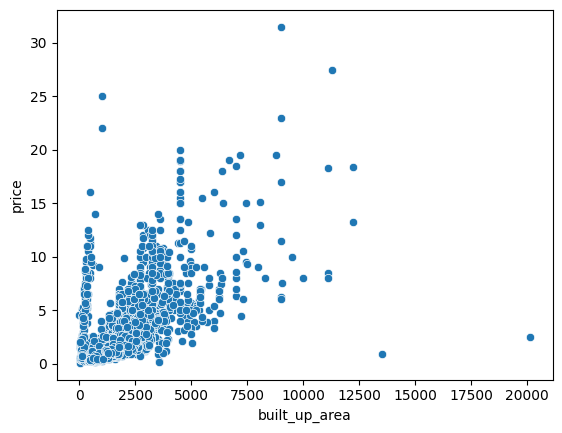

In [78]:
sns.scatterplot(data=df,x='built_up_area',y='price')

In [79]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [80]:
anamoly_df.sample(5)

,price,area,built_up_area
224,3.50,1620.0,1620.0
412,5.15,3660.0,340.0
2301,2.90,1975.0,1787.0
2479,2.70,1650.0,1833.0
918,2.95,1449.0,1000.0


In [81]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [82]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

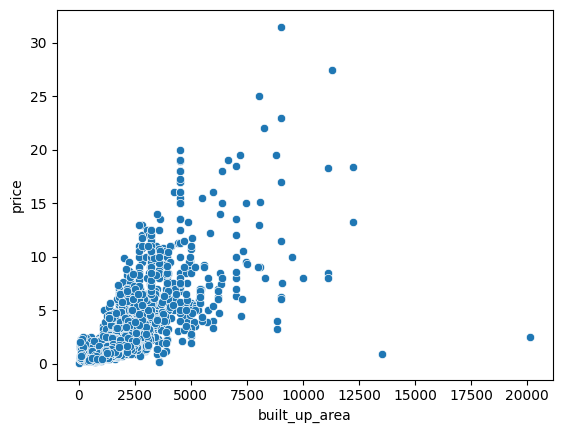

In [83]:
sns.scatterplot(data=df,x='built_up_area',y='price')

In [84]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [85]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,4,4,3,4.0,NaN,Undefined,1743.0,0,0,0,0,0,0,0
1,flat,sare green parc phase 3,sector 92,1.08,5150.0,4,4,2,16.0,NaN,New Property,1891.0,0,1,0,0,0,0,107
2,house,unitech uniworld resorts,sector 33,8.00,11429.0,4,4,3+,2.0,West,Old Property,7000.0,1,1,1,1,0,0,77
3,flat,ireo the corridors,sector 67a,1.60,9265.0,3,3,2,3.0,North,New Property,1346.0,0,0,1,0,0,1,142
4,house,rwa sector 46,sector 46,4.50,24390.0,6,6,3+,3.0,North-East,Moderately Old,1845.0,0,0,1,0,0,1,80


In [86]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [87]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
167,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,0,0
210,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,0,0
359,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,0,88
408,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,0,0
829,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0
887,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,0,0
993,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0
1036,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
1301,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,0,0
2127,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0


In [88]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [89]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_12680\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [90]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### facing

In [91]:
1011/df.shape[0]

0.2843881856540084

<Axes: ylabel='count'>

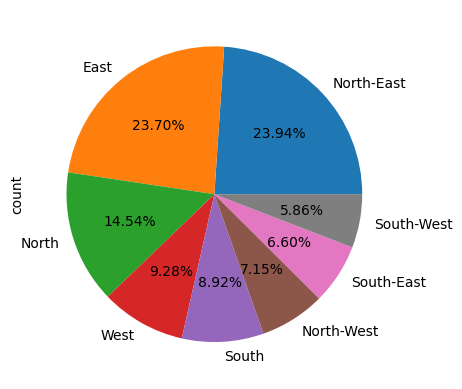

In [92]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [93]:
df.drop(columns=['facing'],inplace=True)

In [94]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1116,house,independent,sector 43,2.50,2885.0,7,7,3,4.0,Relatively New,963.0,0,0,0,0,1,1,20
455,flat,umang winter hills,sector 77,1.10,5296.0,3,4,3+,9.0,Relatively New,1829.0,0,1,0,0,0,0,49
405,flat,ats triumph,sector 104,2.00,8734.0,3,4,3+,4.0,Relatively New,2072.0,0,1,0,0,0,0,60
2104,flat,breez global hill view,sohna road,0.42,7179.0,2,2,1,18.0,Relatively New,650.0,0,0,0,0,0,0,44
3391,flat,irwo westend towers,sector 47,0.65,12059.0,1,1,2,3.0,Old Property,599.0,0,0,0,0,0,0,56


In [95]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [96]:
index=df[df['society'].isnull()].index

In [97]:
df.drop(index=index,inplace=True)

In [98]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [99]:
df['agePossession'].value_counts()

agePossession
Relatively New        1607
New Property           556
Moderately Old         545
Old Property           292
Undefined              291
Under Construction     263
Name: count, dtype: int64

In [100]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sare crescent parc royal greens phase 1,sector 92,0.85,4877.0,4,4,3,4.0,Undefined,1743.0,0,0,0,0,0,0,0
5,flat,housing apna enclave,sector 4,0.39,4105.0,2,2,1,1.0,Undefined,950.0,0,0,0,0,0,0,0
10,flat,smart world gems,sector 89,0.88,7978.0,2,2,0,2.0,Undefined,1103.0,0,0,0,0,0,0,45
63,flat,assotech blith,sector 99,1.60,6667.0,3,4,0,15.0,Undefined,2400.0,0,0,0,0,0,0,51
64,flat,ramprastha the edge towers,sector 37d,1.10,5528.0,3,3,3,9.0,Undefined,1990.0,0,0,0,0,0,0,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3521,house,independent,sector 4,0.70,6648.0,3,3,0,1.0,Undefined,117.0,0,0,0,0,0,0,0
3522,flat,gls arawali homes,sohna road,0.32,6723.0,2,1,0,0.0,Undefined,476.0,0,0,0,0,0,0,0
3534,flat,avl 36 gurgaon,sector 36a,0.50,8333.0,1,1,1,5.0,Undefined,600.0,0,0,0,0,0,0,0
3545,house,ninex city,sector 76,1.75,6250.0,4,4,0,14.0,Undefined,3111.0,0,0,0,0,0,0,0


In [101]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [102]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [103]:
df['agePossession'].value_counts()

agePossession
Relatively New        1719
New Property           596
Moderately Old         584
Old Property           325
Under Construction     277
Undefined               53
Name: count, dtype: int64

In [104]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [105]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [106]:
df['agePossession'].value_counts()

agePossession
Relatively New        1728
New Property           597
Moderately Old         591
Old Property           328
Under Construction     277
Undefined               33
Name: count, dtype: int64

In [107]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [108]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [109]:
df['agePossession'].value_counts()

agePossession
Relatively New        1730
Moderately Old         622
New Property           597
Old Property           328
Under Construction     277
Name: count, dtype: int64

In [110]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [114]:
# Create the folder if it doesn't exist
os.makedirs("../data/feature_engineered", exist_ok=True)

df.to_csv("../data/feature_engineered/gurgaon_properties_missing_value_imputation.csv", index=False)

print("Missing value imputation dataset saved successfully!")

Missing value imputation dataset saved successfully!


In [115]:
df.shape

(3554, 18)